In [ ]:
!pip install opencv-python opencv-contrib-python


In [ ]:
import os
import cv2
import numpy as np
import urllib.request
from matplotlib import pyplot as plt

# Crear carpetas
os.makedirs("cam1", exist_ok=True)
os.makedirs("cam2", exist_ok=True)

# URLs de imágenes monoculares (mismo tablero desde distintos ángulos)
img_urls = [
    "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/left01.jpg",
    "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/left02.jpg",
    "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/left03.jpg",
    "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/left04.jpg",
    "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/left05.jpg"
]

for i, url in enumerate(img_urls):
    urllib.request.urlretrieve(url, f"cam1/left{i:02d}.jpg")

# Para estéreo, descargar pares left-right
stereo_urls = {
    "left": [
        "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/left01.jpg",
        "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/left02.jpg"
    ],
    "right": [
        "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/right01.jpg",
        "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/right02.jpg"
    ]
}

for i, (l_url, r_url) in enumerate(zip(stereo_urls["left"], stereo_urls["right"])):
    urllib.request.urlretrieve(l_url, f"cam1/left{i:02d}.jpg")
    urllib.request.urlretrieve(r_url, f"cam2/right{i:02d}.jpg")


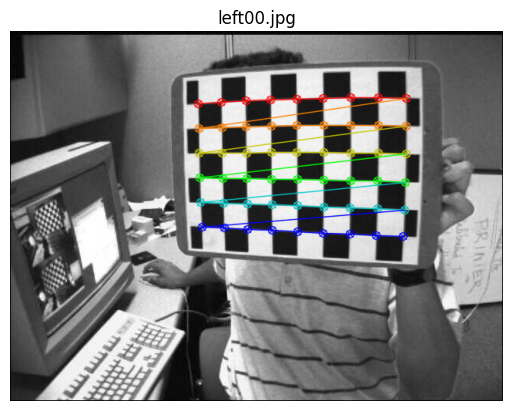

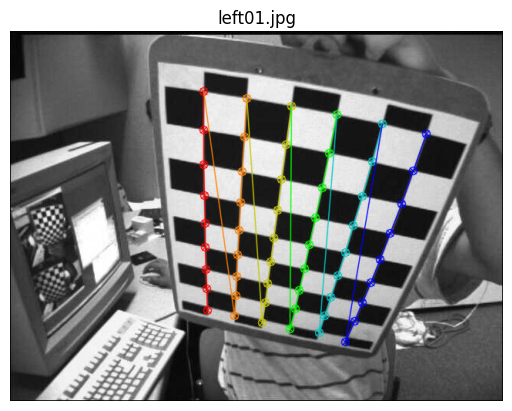

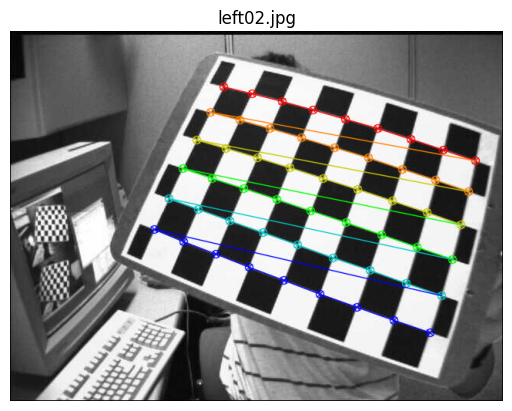

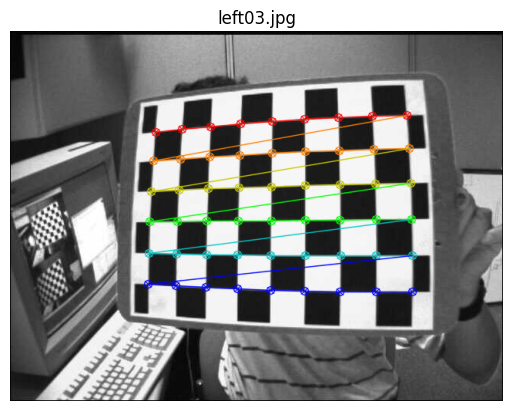

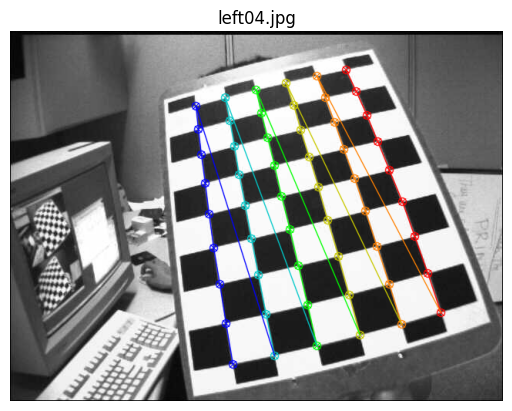


✅ Error medio de reproyección: 0.05317 píxeles
Matriz de cámara:
 [[538.43383995   0.         338.31871887]
 [  0.         538.47474706 237.83443941]
 [  0.           0.           1.        ]]
Coeficientes de distorsión:
 [[-0.25650256 -0.02652635  0.00340442 -0.00166006  0.13245449]]


In [ ]:
pattern_size = (9, 6)
square_size = 0.025  # metros
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

objp = np.zeros((pattern_size[0]*pattern_size[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:pattern_size[0], 0:pattern_size[1]].T.reshape(-1, 2)
objp *= square_size

objpoints = []
imgpoints = []

images = sorted(os.listdir("cam1"))

for fname in images:
    img = cv2.imread(os.path.join("cam1", fname))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ret, corners = cv2.findChessboardCorners(gray, pattern_size, None)
    if ret:
        corners2 = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
        imgpoints.append(corners2)
        objpoints.append(objp)
        # Mostrar esquinas
        img = cv2.drawChessboardCorners(img, pattern_size, corners2, ret)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(fname)
        plt.axis("off")
        plt.show()

ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)
# Validación: reproyección de los puntos
total_error = 0
for i in range(len(objpoints)):
    imgpoints_proj, _ = cv2.projectPoints(objpoints[i], rvecs[i], tvecs[i], mtx, dist)
    error = cv2.norm(imgpoints[i], imgpoints_proj, cv2.NORM_L2) / len(imgpoints_proj)
    total_error += error

mean_error = total_error / len(objpoints)
print(f"\n✅ Error medio de reproyección: {mean_error:.5f} píxeles")

print("Matriz de cámara:\n", mtx)
print("Coeficientes de distorsión:\n", dist)


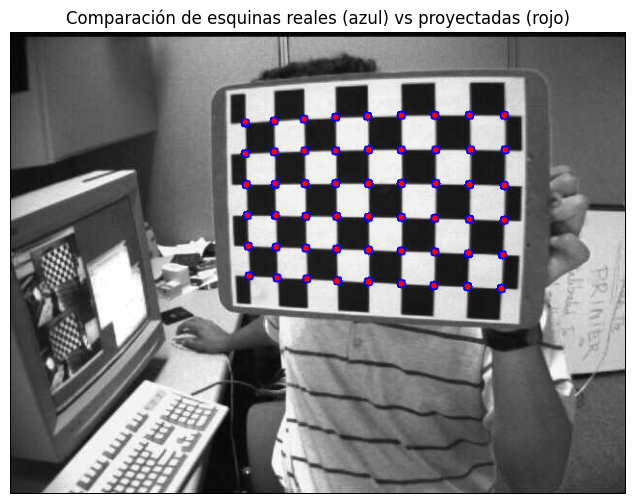

In [ ]:
# Mostrar una imagen con los puntos detectados vs reproyectados
idx = 0  # índice de imagen
img = cv2.imread("cam1/" + images[idx])
img_draw = img.copy()

# Proyectar puntos 3D
imgpoints_proj, _ = cv2.projectPoints(objpoints[idx], rvecs[idx], tvecs[idx], mtx, dist)

# Dibujar puntos reales (azul) y proyectados (rojo)
for real, proj in zip(imgpoints[idx], imgpoints_proj):
    x1, y1 = real.ravel()
    x2, y2 = proj.ravel()
    cv2.circle(img_draw, (int(x1), int(y1)), 5, (255, 0, 0), -1)  # Azul: esquina real
    cv2.circle(img_draw, (int(x2), int(y2)), 3, (0, 0, 255), -1)  # Rojo: reproyección

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB))
plt.title("Comparación de esquinas reales (azul) vs proyectadas (rojo)")
plt.axis("off")
plt.show()


# Calibracion estereo, dos camaras

In [ ]:
# Obtener puntos de ambas cámaras
imgpoints1 = []
imgpoints2 = []
objpoints_stereo = []

left_images = sorted([f for f in os.listdir("cam1") if "left" in f])
right_images = sorted([f for f in os.listdir("cam2") if "right" in f])

for lf, rf in zip(left_images, right_images):
    imgL = cv2.imread(f"cam1/{lf}")
    imgR = cv2.imread(f"cam2/{rf}")
    grayL = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
    grayR = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)

    retL, cornersL = cv2.findChessboardCorners(grayL, pattern_size, None)
    retR, cornersR = cv2.findChessboardCorners(grayR, pattern_size, None)

    if retL and retR:
        cornersL2 = cv2.cornerSubPix(grayL, cornersL, (11, 11), (-1, -1), criteria)
        cornersR2 = cv2.cornerSubPix(grayR, cornersR, (11, 11), (-1, -1), criteria)
        objpoints_stereo.append(objp)
        imgpoints1.append(cornersL2)
        imgpoints2.append(cornersR2)

# Calibración estéreo
flags = cv2.CALIB_FIX_INTRINSIC
ret, _, _, _, _, R, T, E, F = cv2.stereoCalibrate(
    objpoints_stereo, imgpoints1, imgpoints2,
    mtx, dist, mtx, dist, grayL.shape[::-1],
    criteria=criteria, flags=flags)

print("Rotación entre cámaras:\n", R)
print("Traslación (baseline):\n", T)


Rotación entre cámaras:
 [[ 0.99974921  0.00666723 -0.02137908]
 [-0.00625018  0.99979003  0.01951495]
 [ 0.0215047  -0.01937643  0.99958096]]
Traslación (baseline):
 [[-0.08387801]
 [ 0.00144935]
 [-0.00269362]]


In [ ]:
R1, R2, P1, P2, Q, _, _ = cv2.stereoRectify(
    mtx, dist, mtx, dist,
    grayL.shape[::-1], R, T, alpha=0)

print("Matriz Q (reproyección 3D):\n", Q)

Matriz Q (reproyección 3D):
 [[   1.            0.            0.         -324.45014572]
 [   0.            1.            0.         -240.66789627]
 [   0.            0.            0.          524.15961848]
 [   0.            0.           11.91415642   -0.        ]]


In [ ]:
np.savez("calibracion_camaras.npz", mtx=mtx, dist=dist, R=R, T=T, Q=Q)

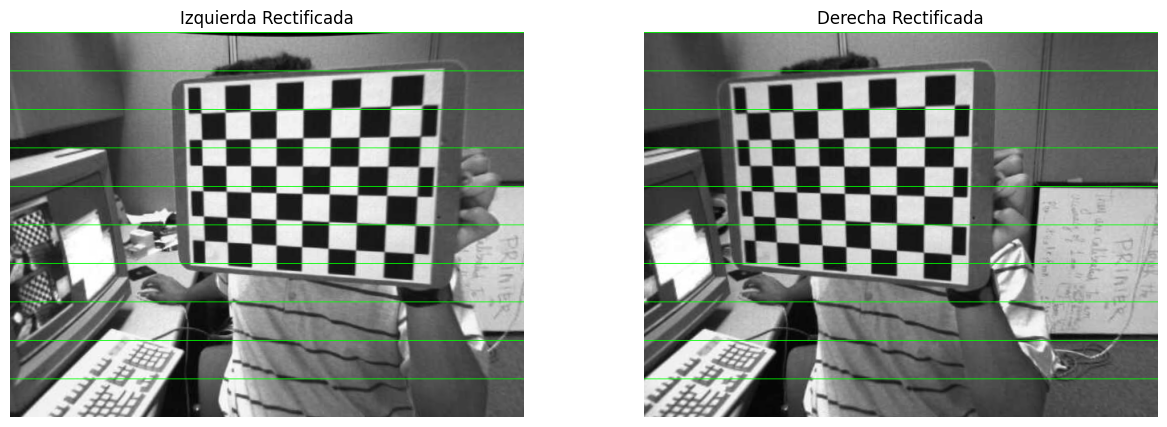

In [ ]:
# Cargar una pareja para mostrar la rectificación
imgL = cv2.imread("cam1/" + left_images[0])
imgR = cv2.imread("cam2/" + right_images[0])

# Crear mapas de remapeo
map1x, map1y = cv2.initUndistortRectifyMap(mtx, dist, R1, P1, grayL.shape[::-1], cv2.CV_16SC2)
map2x, map2y = cv2.initUndistortRectifyMap(mtx, dist, R2, P2, grayR.shape[::-1], cv2.CV_16SC2)

# Aplicar remapeo
rectifiedL = cv2.remap(imgL, map1x, map1y, cv2.INTER_LINEAR)
rectifiedR = cv2.remap(imgR, map2x, map2y, cv2.INTER_LINEAR)

# Dibujar líneas horizontales
def draw_lines(imgL, imgR, n_lines=10):
    h, w = imgL.shape[:2]
    spacing = h // n_lines
    for i in range(n_lines):
        y = i * spacing
        cv2.line(imgL, (0, y), (w, y), (0, 255, 0), 1)
        cv2.line(imgR, (0, y), (w, y), (0, 255, 0), 1)
    return imgL, imgR

rectifiedL_lines, rectifiedR_lines = draw_lines(rectifiedL.copy(), rectifiedR.copy())

# Mostrar lado a lado
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(rectifiedL_lines, cv2.COLOR_BGR2RGB))
plt.title("Izquierda Rectificada")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(rectifiedR_lines, cv2.COLOR_BGR2RGB))
plt.title("Derecha Rectificada")
plt.axis("off")

plt.show()
